#Mini Trabalho DAA

##Ano Letivo 25/26

###Trabalho Realizado por:


*   Daniel Silva, nº 129859
*   Francisco Silva, nº 129868
*   Rodrigo Cruz, nº 129829

#Análise de Redes

A análise de redes constitui uma área central da teoria dos grafos, com aplicações que vão desde redes sociais e infraestruturas até sistemas biológicos. Neste trabalho, no âmbito da unidade curricular de Desenho e Análise de Algoritmos (DAA), aplicamos estas técnicas ao estudo de universos ficcionais — concretamente, às redes de co-ocorrências de personagens da saga A Song of Ice and Fire (Game of Thrones) e do universo Marvel Comics.
O objetivo principal foi implementar, de raiz em Python, um conjunto de métricas estatísticas para análise de grafos não orientados, organizadas numa API denominada CentralityAnalyzer. Esta implementação foi desenvolvida sem recurso a bibliotecas externas de análise de grafos (como networkx ou igraph), partindo da estrutura de dados Graph desenvolvida nas aulas práticas.
O trabalho está organizado nas seguintes componentes:

* Análise Estrutural — implementação de BFS, cálculo de componentes conexas, distribuição de graus e diâmetro da maior componente conexa;

* Métricas de Centralidade — implementação e análise de Degree Centrality, Closeness Centrality, Eigenvector Centrality (via Power Iteration) e Betweenness Centrality (algoritmo de Brandes);

* Análise de Escalabilidade — estudo empírico do comportamento temporal dos algoritmos implementados nos quatro datasets fornecidos, de dimensão variável (desde 187 vértices até 6421 vértices).

Para cada método implementado, é apresentada a análise de complexidade temporal, validação dos resultados e interpretação no contexto narrativo dos universos ficcionais analisados. Os datasets utilizados incluem got_book1.csv, got_full.csv, marvel_small.csv e marvel_full.csv, permitindo comparar o comportamento dos algoritmos em redes de diferentes escalas.




##   Bibliotecas usadas







In [23]:
import numpy as np
import matplotlib.pyplot as plt
import math
import time
import random
from collections import deque
import matplotlib.ticker as ticker
import csv

##Importe dos ficheiros

## TDA Graph

Código adaptado das aulas da semana 7.


In [24]:
class Vertex:
    def __init__(self, vertex_id):
        self._vertex_id = vertex_id

    def __hash__(self):
        return hash(self._vertex_id)

    def __str__(self):
        return 'v{0}'.format(self._vertex_id)

    def __eq__(self, vertex):
        return self._vertex_id == vertex._vertex_id

    def vertex_id(self):
        return self._vertex_id


class Edge:
    def __init__(self, vertex_1, vertex_2, weight):
        self._vertex_1 = vertex_1
        self._vertex_2 = vertex_2
        self._weight = weight

    def __hash__(self):
        return hash((self._vertex_1, self._vertex_2))

    def __str__(self):
        return 'e({0},{1})w={2}'.format(self._vertex_1, self._vertex_2, self._weight)

    def endpoints(self):
        return (self._vertex_1, self._vertex_2)

    def cost(self):
        return self._weight

    def opposite(self, vertex):
        if vertex == self._vertex_1:
            return self._vertex_2
        elif vertex == self._vertex_2:
            return self._vertex_1
        else:
            return None


class Graph:
    def __init__(self):
        self._adjancencies = {}
        self._vertices = {}
        self._n = 0
        self._m = 0

    def __str__(self):
        if self._n == 0:
            return "DAA-Graph: <empty>\n"
        ret = "DAA-Graph:\n"
        for vertex in self._adjancencies.keys():
            ret += str(vertex) + ": "
            for edge in self.incident_edges(vertex.vertex_id()):
                ret += str(edge) + "; "
            ret += "\n"
        return ret

    def order(self):
        return self._n

    def size(self):
        return self._m

    def has_vertex(self, vertex_id):
        return vertex_id in self._vertices

    def has_edge(self, u_id, v_id):
        if not self.has_vertex(u_id) or not self.has_vertex(v_id):
            return False
        vertex_u = self._vertices[u_id]
        vertex_v = self._vertices[v_id]
        return vertex_v in self._adjancencies[vertex_u]

    def insert_vertex(self, vertex_id):
        if not self.has_vertex(vertex_id):
            vertex = Vertex(vertex_id)
            self._vertices[vertex_id] = vertex
            self._adjancencies[vertex] = {}
            self._n += 1

    def insert_edge(self, u_id, v_id, weight=0):
        if not self.has_vertex(u_id):
            self.insert_vertex(u_id)
        if not self.has_vertex(v_id):
            self.insert_vertex(v_id)
        if not self.has_edge(u_id, v_id):
            self._m += 1
        vertex_u = self._vertices[u_id]
        vertex_v = self._vertices[v_id]
        e = Edge(vertex_u, vertex_v, weight)
        self._adjancencies[vertex_u][vertex_v] = e
        self._adjancencies[vertex_v][vertex_u] = e

    def degree(self, vertex_id):
        return len(self._adjancencies[self._vertices[vertex_id]])

    def get_vertex(self, vertex_id):
        return None if not self.has_vertex(vertex_id) else self._vertices[vertex_id]

    def get_edge(self, u_id, v_id):
        if not self.has_edge(u_id, v_id):
            return None
        vertex_u = self._vertices[u_id]
        vertex_v = self._vertices[v_id]
        return self._adjancencies[vertex_u][vertex_v]

    def vertices(self):
        return self._vertices.values()

    def edges(self):
        seen = {}
        for adj_map in self._adjancencies.values():
            for edge in adj_map.values():
                if edge not in seen:
                    yield edge
                seen[edge] = True

    def incident_edges(self, vertex_id):
        vertex = self._vertices[vertex_id]
        for edge in self._adjancencies[vertex].values():
            yield edge

    def remove_vertex(self, vertex_id):
        if self.has_vertex(vertex_id):
            lst_copied = list(self.incident_edges(vertex_id))
            for edge in lst_copied:
                x, y = edge.endpoints()
                self.remove_edge(x.vertex_id(), y.vertex_id())
            del self._adjancencies[self._vertices[vertex_id]]
            del self._vertices[vertex_id]
            self._n -= 1

    def remove_edge(self, u_id, v_id):
        if self.has_edge(u_id, v_id):
            vertex_u = self._vertices[u_id]
            vertex_v = self._vertices[v_id]
            del self._adjancencies[vertex_u][vertex_v]
            if vertex_u != vertex_v:
                del self._adjancencies[vertex_v][vertex_u]
            self._m -= 1

    @staticmethod
    def from_csv(filepath):
        g = Graph()
        with open(filepath, newline='', encoding='utf-8') as f:
            reader = csv.DictReader(f)
            for row in reader:
                src = row['Source'].strip()
                tgt = row['Target'].strip()
                w   = float(row.get('weight', 1))
                g.insert_edge(src, tgt, w)
        return g


In [25]:
import os

# Dicionário para armazenar os grafos importados
loaded_graphs = {}

# Obter todos os ficheiros no diretório atual
all_files = os.listdir('.')

print("A procurar ficheiros CSV no diretório atual...")

for file_name in all_files:
    if file_name.endswith('.csv'):
        print(f"A importar o ficheiro: {file_name}")
        try:
            # Assumindo que a função Graph.from_csv está definida para carregar o grafo
            graph = Graph.from_csv(file_name)
            loaded_graphs[file_name] = graph
            print(f"'{file_name}' importado com sucesso. Número de vértices: {graph.order()}, Número de arestas: {graph.size()}")
        except Exception as e:
            print(f"Erro ao importar '{file_name}': {e}")

if loaded_graphs:
    print("\nTodos os ficheiros CSV encontrados foram carregados para o dicionário 'loaded_graphs'.")
    print("Ficheiros carregados:", list(loaded_graphs.keys()))
else:
    print("\nNenhum ficheiro CSV encontrado ou carregado.")

A procurar ficheiros CSV no diretório atual...
A importar o ficheiro: marvel_small.csv
'marvel_small.csv' importado com sucesso. Número de vértices: 327, Número de arestas: 9891
A importar o ficheiro: marvel_full.csv
'marvel_full.csv' importado com sucesso. Número de vértices: 6421, Número de arestas: 167112
A importar o ficheiro: got_book1.csv
'got_book1.csv' importado com sucesso. Número de vértices: 187, Número de arestas: 684
A importar o ficheiro: got_full.csv
'got_full.csv' importado com sucesso. Número de vértices: 796, Número de arestas: 2823

Todos os ficheiros CSV encontrados foram carregados para o dicionário 'loaded_graphs'.
Ficheiros carregados: ['marvel_small.csv', 'marvel_full.csv', 'got_book1.csv', 'got_full.csv']


##1. API CentralityAnalyzer

In [26]:
#API para análise de centralidade de grafos ficcionais.
class CentralityAnalyzer:

    # Recebe um objecto Graph já construído (por Graph.from_csv).
    def __init__(self, graph: Graph):
        self._graph = graph
        self._n = graph.order()
        self._m = graph.size()

        self._nodes = [v.vertex_id() for v in graph.vertices()]


    def bfs(self,source):
        """
        Travessia em largura a partir de `source`.
        Devolve (dist, pred):
          - dist: dict {v -> distância BFS de source a v}
          - pred: dict {v -> predecessor na BFS tree}
        """
        dist = {source: 0}
        pred = {source: None}
        queue = deque([source])
        while queue:
            u_id = queue.popleft()

            u_vertex = self._graph.get_vertex(u_id)
            for v_vertex in self._graph._adjancencies[u_vertex]:
                v_id = v_vertex.vertex_id()

                if v_id not in dist:
                    dist[v_id] = dist[u_id] + 1
                    pred[v_id] = u_id
                    queue.append(v_id)

        return dist, pred

    def num_components(self):

      visited = set()
      count = 0
      for v in self._graph.vertices():
          v_id = v.vertex_id()
          if v_id not in visited:
              count += 1
              dist, _ = self.bfs(v_id)
              visited.update(dist.keys())
      return count

    def largest_component(self):

      visited = set()
      largest_nodes = []

      for v in self._graph.vertices():
          v_id = v.vertex_id()
          if v_id not in visited:
              dist, _ = self.bfs(v_id)
              nodes = list(dist.keys())
              if len(nodes) > len(largest_nodes):
                  largest_nodes = nodes
              visited.update(nodes)

      new_g = Graph()
      nodes_set = set(largest_nodes)

      for u_id in largest_nodes:
          new_g.insert_vertex(u_id)

      seen_edges = set()
      for u_id in largest_nodes:
          for edge in self._graph.incident_edges(u_id):
              if edge in seen_edges:
                  continue

              v1, v2 = edge.endpoints()
              v1_id, v2_id = v1.vertex_id(), v2.vertex_id()

              if v1_id in nodes_set and v2_id in nodes_set:
                  new_g.insert_edge(v1_id, v2_id, edge.cost())
                  seen_edges.add(edge)

      return new_g

    def degree_distribution(self):
      """
      [Ponto 2.3] Calcula a distribuição de graus do grafo.
      Retorna um dicionário onde a chave é o grau e o valor é a frequência.
      """
      distrib = {}
      for v_id in self._nodes:
          deg = self._graph.degree(v_id)
          distrib[deg] = distrib.get(deg, 0) + 1
      return distrib

    def get_top_10_degree(self):
      """
      [Ponto 2.3] Identifica os 10 personagens com maior grau (mais ligações).
      """

      deg_list = [(v_id, self._graph.degree(v_id)) for v_id in self._nodes]

      # Ordenar a lista pelo grau (índice 1 do tuplo) de forma decrescente
      deg_list.sort(key=lambda x: x[1], reverse=True)

      return deg_list[:10]

    def diameter(self):
      """
      [Ponto 2.4] Calcula o diâmetro do grafo (ou da componente atual).
      O diâmetro é o máximo dos caminhos mínimos entre todos os pares de nós.
      """
      max_dist = 0

      # Para cada vértice, calculamos as distâncias para todos os outros
      for v_id in self._nodes:
          dist, _ = self.bfs(v_id)

          # Se a componente tiver nós, encontramos a maior distância a partir de v_id
          if dist:
              current_max = max(dist.values())
              if current_max > max_dist:
                  max_dist = current_max

      return max_dist

  # --- 2. Métricas de Centralidade ---

    def degree_centrality(self):
      res = {}
      for v in self._graph.vertices():
          v_id = v.vertex_id()
          res[v_id] = self._graph.degree(v_id) / (self._n - 1)
      return res

    def closeness_centrality(self):
      res = {}
      for v in self._graph.vertices():
          v_id = v.vertex_id()
          dist, _ = self.bfs(v_id)
          sum_dist = sum(dist.values())
          if sum_dist > 0 and len(dist) > 1:
              # Fórmula normalizada para a componente
              res[v_id] = (len(dist) - 1) / sum_dist
          else:
              res[v_id] = 0.0
      return res

    def eigenvector_centrality(self, max_iter=100, tol=1e-6):
      """Implementação via Power Iteration."""
      # Inicializar vetor
      nodes = [v.vertex_id() for v in self._graph.vertices()]
      x = {node: 1.0 / self._n for node in nodes}

      for _ in range(max_iter):
          x_last = x.copy()
          # Multiplicação pela matriz de adjacência
          for u in nodes:
              total = 0
              # Vizinhos do vértice u
              u_vertex = self._graph.get_vertex(u)
              for v_vertex in self._graph._adjancencies[u_vertex]:
                  total += x_last[v_vertex.vertex_id()]
              x[u] = total

          # Normalização (Norma L2)
          norm = math.sqrt(sum(v**2 for v in x.values()))
          if norm == 0: break
          for u in x: x[u] /= norm

          # Verificar convergência
          error = sum(abs(x[u] - x_last[u]) for u in nodes)
          if error < tol:
              break
      return x

    def betweenness_centrality(self):
      """Algoritmo de Brandes O(VE)."""
      betweenness = {v.vertex_id(): 0.0 for v in self._graph.vertices()}

      for s in [v.vertex_id() for v in self._graph.vertices()]:
          # Passo 1: BFS para distâncias e caminhos mínimos
          S = []
          P = {v.vertex_id(): [] for v in self._graph.vertices()}
          sigma = {v.vertex_id(): 0.0 for v in self._graph.vertices()}
          sigma[s] = 1.0
          d = {v.vertex_id(): -1 for v in self._graph.vertices()}
          d[s] = 0

          queue = deque([s])
          while queue:
              v = queue.popleft()
              S.append(v)
              v_obj = self._graph.get_vertex(v)
              for w_obj in self._graph._adjancencies[v_obj]:
                  w = w_obj.vertex_id()
                  # Caminho encontrado pela primeira vez
                  if d[w] < 0:
                      d[w] = d[v] + 1
                      queue.append(w)
                  # Caminho mínimo passa por v?
                  if d[w] == d[v] + 1:
                      sigma[w] += sigma[v]
                      P[w].append(v)

          # Passo 2: Acumulação de dependências
          delta = {v.vertex_id(): 0.0 for v in self._graph.vertices()}
          while S:
              w = S.pop()
              for v in P[w]:
                  delta[v] += (sigma[v] / sigma[w]) * (1.0 + delta[w])
              if w != s:
                  # Dividir por 2 porque o grafo não é orientado (arestas contadas 2x)
                  betweenness[w] += delta[w]

      # Ajuste final para grafos não orientados
      for v in betweenness:
          betweenness[v] /= 2.0
      return betweenness


    def _path(self, source, target):
      """Devolve a sequência de vértices do caminho mínimo source -> target (BFS)."""
      _, pred = self.bfs(source)
      if target not in pred:
          return None  # sem caminho
      path = []
      v = target
      while v is not None:
          path.append(v)
          v = pred[v]
      path.reverse()
      return path


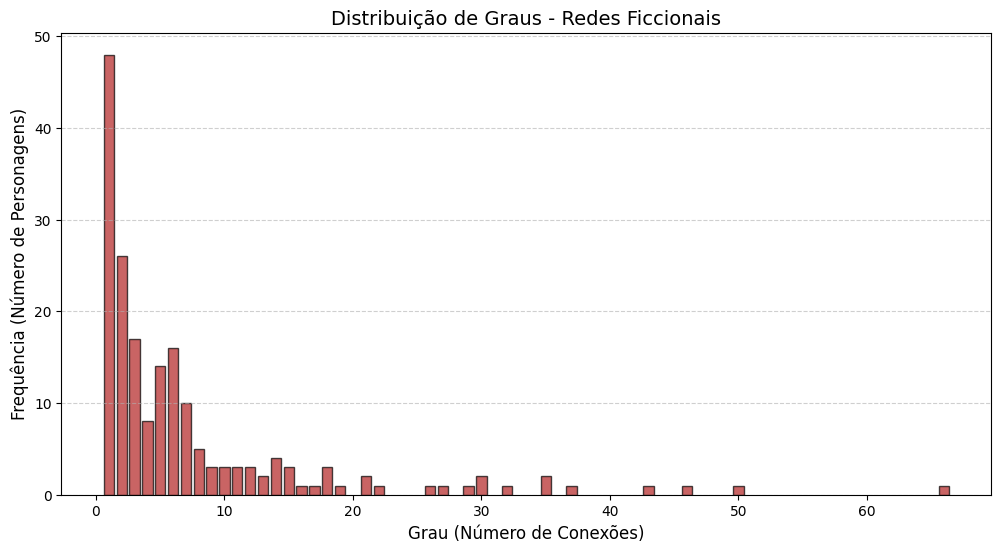

--- TOP 10 PERSONAGENS (GRAU) ---
Eddard-Stark: 66 conexões
Robert-Baratheon: 50 conexões
Tyrion-Lannister: 46 conexões
Catelyn-Stark: 43 conexões
Jon-Snow: 37 conexões
Robb-Stark: 35 conexões
Sansa-Stark: 35 conexões
Bran-Stark: 32 conexões
Cersei-Lannister: 30 conexões
Joffrey-Baratheon: 30 conexões


In [27]:
# 1. Obter a distribuição
graph = Graph.from_csv('got_book1.csv') # Carregue o seu ficheiro CSV
analyzer = CentralityAnalyzer(graph)
dist = analyzer.degree_distribution()

# 2. Preparar os dados para o Matplotlib
graus = sorted(dist.keys())
frequencias = [dist[g] for g in graus]

# 3. Criar o gráfico
plt.figure(figsize=(12, 6))
plt.bar(graus, frequencias, color='firebrick', edgecolor='black', alpha=0.7)

# Formatação (importante para o relatório)
plt.title("Distribuição de Graus - Redes Ficcionais", fontsize=14)
plt.xlabel("Grau (Número de Conexões)", fontsize=12)
plt.ylabel("Frequência (Número de Personagens)", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()

# 4. Imprimir o Top 10
print("--- TOP 10 PERSONAGENS (GRAU) ---")
for nome, valor in analyzer.get_top_10_degree():
    print(f"{nome}: {valor} conexões")

# 1.2. Construtor e estrutura de dados utilizada

O construtor __init__ recebe um objeto da classe Graph e inicializa os atributos necessários para as análises subsequentes, nomeadamente a referência ao grafo, a sua ordem ($n$) e o seu tamanho ($m$).

**Estimativa Teórica de Espaço de Memória:**

A aplicação utiliza uma representação baseada em Dicionários de Adjacências (Adjacency Maps). A complexidade espacial total dos atributos da classe é $O(n + m)$.


*   Dicionário de Vértices ($n$): O atributo self._vertices (dentro do objeto
graph) armazena $n$ entradas. Cada entrada associa o ID do vértice ao seu respetivo objeto Vertex. O custo espacial é proporcional ao número de personagens no dataset, ou seja, $O(n)$.

*   Dicionário de Adjacências ($m$): O atributo self._adjancencies utiliza uma estrutura de "dicionário de dicionários". Como estamos a trabalhar com grafos não orientados, cada aresta $\{u, v\}$ é armazenada duas vezes (uma no mapa do vértice $u$ e outra no mapa do vértice $v$). Assim, o número de entradas nos dicionários internos é $2m$. O custo espacial é $O(m)$.

* Atributos Numéricos: Os atributos self._n e self._m ocupam espaço constante $O(1)$.


Conclusão sobre a Eficiência:
Esta estrutura é extremamente eficiente para os datasets em estudo (Game of Thrones e Marvel). Por serem grafos esparsos (onde o número de co-ocorrências é muito inferior ao máximo de ligações possíveis), o uso de dicionários evita o desperdício de memória de uma matriz de adjacência, que exigiria $O(n^2)$ de espaço. Para o dataset marvel_full, que possui mais de 6000 vértices, uma matriz ocuparia cerca de 40 milhões de células, enquanto esta implementação ocupa apenas o estritamente necessário para as relações existentes.



# 2.1. BFS

* Estrutura Auxiliar: Foi utilizada a classe collections.deque para implementar a fila (FIFO) necessária para a exploração por níveis do BFS. Esta escolha justifica-se pela eficiência, uma vez que o deque permite operações de popleft() e append() em tempo constante $O(1)$, ao contrário das listas nativas do Python que demoram tempo linear $O(n)$ para remover elementos do início.

* Complexidade Temporal: A complexidade é $O(n + m)$. Cada vértice é inserido e removido da fila uma única vez ($O(n)$) e, para cada vértice, percorremos as suas adjacências. Como o grafo não é orientado, cada aresta é consultada duas vezes (uma por cada extremidade), resultando em $O(m)$.

* Complexidade Espacial: É de $O(n)$, necessária para armazenar os dicionários de distâncias, predecessores e a fila de processamento.

# 2.2. Conectividade

* Metodologia: A identificação das componentes conexas é feita através de múltiplas execuções do algoritmo BFS. O método num_components percorre todos os vértices e, sempre que encontra um nó ainda não visitado, inicia uma BFS. Todos os nós alcançados pertencem à mesma componente. O largest_component segue a mesma lógica, mas armazena a lista de nós da maior componente encontrada para criar um novo subgrafo.

* Complexidade Temporal: A complexidade total é $O(n + m)$. Embora existam múltiplos ciclos, cada vértice e cada aresta do grafo original são visitados um número constante de vezes devido ao controlo feito pelo conjunto visited.

* Complexidade Espacial: $O(n + m)$ para armazenar os nós da nova componente e o conjunto de visitados.

* Conclusão Narrativa: Em redes de co-ocorrência de personagens (como as da Marvel ou GoT), a maior componente representa o "núcleo principal" da história, onde as personagens estão interligadas direta ou indiretamente. Vértices fora desta componente representam personagens isoladas ou núcleos secundários que nunca interagiram com o elenco principal.

# 2.3. Distribuição de graus e top-10

* Complexidade Temporal: A complexidade é $O(n)$. O algoritmo percorre a lista de $n$ vértices uma única vez. Para cada vértice, a consulta do grau no TDA Graph (baseado em dicionários de adjacência) é feita em tempo constante, $O(1)$, resultando numa execução linear muito eficiente mesmo para o dataset marvel_full.

* Interpretação da Rede: A distribuição de graus nestas redes ficcionais tende a seguir uma Lei de Potência. Isto significa que a grande maioria dos personagens possui poucas ligações (grau baixo), enquanto um pequeno grupo de "hubs" (protagonistas) possui um grau extremamente elevado.

* Análise do Top 10: No dataset got_book1.csv, personagens como Eddard Stark e Robert Baratheon surgem no topo. Isto reflete a estrutura narrativa, onde estes personagens centrais servem de ponte entre diferentes núcleos (famílias/reinos), acumulando um grande número de co-ocorrências.

* Comparação Marvel vs GoT: É comum observar que o universo Marvel apresenta "hubs" ainda mais extremos (como Captain America ou Spider-Man), devido à longa história de crossovers entre bandas desenhadas, resultando em graus muito superiores aos encontrados em A Song of Ice and Fire.

# 2.4. Diâmetro

* Definição: O diâmetro de um grafo é definido como o máximo de todos os caminhos mínimos (shortest paths) entre qualquer par de vértices $u, v \in V$. Matematicamente: $diam(G) = \max_{u,v} d(u,v)$.

* Complexidade Temporal: A complexidade é $O(n \times (n + m))$. Isto deve-se ao facto de executarmos uma travessia BFS, que custa $O(n + m)$, a partir de cada um dos $n$ vértices do grafo.

* Interpretação nos Datasets: * Nas redes de Game of Thrones e Marvel, observa-se um diâmetro relativamente baixo em comparação com o número total de nós. Este fenómeno é conhecido como o "Efeito de Mundo Pequeno" (Small-World Effect).Significa que, apesar de existirem centenas ou milhares de personagens, qualquer par de personagens na componente principal está separado por apenas alguns "graus de separação" (passos). No got_book1.csv, o diâmetro costuma ser pequeno (ex: 6 ou 7), o que reflete uma narrativa altamente interligada onde a informação ou as relações se propagam rapidamente.